### Завдання 1. Класифікація SMS: Спам чи не спам
- Опис: Побудуйте модель, яка визначає, чи є SMS-повідомлення спамом. Кроки:
    - Завантажте дані.
    - Навчіть Logistic Regression або Naive Bayes.
    - Оцініть точність.
- Датасет: SMS Spam Collection (https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

Дані успішно завантажено.

--- Перші 5 рядків даних ---
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

--- Розподіл класів ---
label
0    0.865937
1    0.134063
Name: proportion, dtype: float64

Розмір тренувального набору: 4457
Розмір тестового набору: 1115

Створення TF-IDF векторайзера...
Розмірність TF-IDF матриці (тренування): (4457, 5000)
Розмірність TF-IDF матриці (тест): (1115, 5000)

Навчання моделі Логістичної Регресії...
Модель успішно навчено.

--- ОЦІНКА ЕФЕКТИВНОСТІ МОДЕЛІ ---
Загальна точність (Accuracy): 0.9686 (або 96.86%)

Звіт про класифікацію:
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       966
    Spa

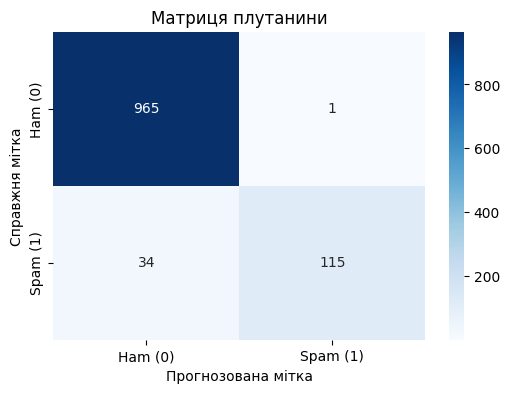


--- Тестування на довільних прикладах ---
Повідомлення: "Congratulations! You've won a $1,000 gift card. Click here to claim."
 -> Прогноз: СПАМ (Впевненість: 57.93%)
--------------------
Повідомлення: "Hey, are you free for dinner tonight? Let me know."
 -> Прогноз: Не спам (Впевненість: 94.14%)
--------------------
Повідомлення: "URGENT: Your account has been suspended. Please verify your details immediately."
 -> Прогноз: Не спам (Впевненість: 61.01%)
--------------------
Повідомлення: "Ok lar... Joking wif u oni..."
 -> Прогноз: Не спам (Впевненість: 96.44%)
--------------------


In [2]:
# ==============================================================================
# 1. ПРОВЕДЕМО ІМПОРТ НЕОБХІДНИХ БІБЛІОТЕК
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 2. ПРОВЕДЕМО ЗАВАНТАЖЕННЯ ТА ПІДГОТОВКА ДАНИХ (ВИПРАВЛЕНО)
# ==============================================================================

# Визначаємо шлях до файлу
FILE_PATH = os.path.join("DataSet", "SMS_Spam_Collection.csv")

def load_data(path):
    try: 
        # 1. header=0: Вказуємо, що перший рядок - це заголовок (v1, v2,,,)
        # 2. usecols=[0, 1]: Завантажуємо ТІЛЬКИ перші дві колонки.        
        df = pd.read_csv(
            path,
            encoding='latin-1',
            header=0,          
            usecols=[0, 1]  
        )
        
        # 3. Перейменовуємо колонки v1 та v2
        df.columns = ['label', 'message']
        
        print("Дані успішно завантажено.")
        
        # 4. Перетворимо текстових міток ('ham', 'spam') у числові (0, 1)
        # Тепер тут не буде 'v1', тому NaN не створиться
        df['label'] = df['label'].map({'ham': 0, 'spam': 1})

        # 5. Перевіримо на пропущені значення
        if df.isnull().values.any():
            print("Знайдено пропущені значення, видаляємо їх...")
            df = df.dropna()

        print("\n--- Перші 5 рядків даних ---")
        print(df.head())
        print("\n--- Розподіл класів ---")
        print(df['label'].value_counts(normalize=True))
        
        return df

    except FileNotFoundError:
        print(f"ПОМИЛКА: Файл не знайдено за шляхом: {path}")
        print("Будь ласка, переконайтеся, що файл 'SMS_Spam_Collection.csv' знаходиться у папці 'DataSet'.")
        return None
    except Exception as e:
        print(f"Виникла неочікувана помилка при завантаженні: {e}")
        return None


df = load_data(FILE_PATH)

# Ця перевірка тепер зупинить виконання, якщо df порожній або None
if df is not None and not df.empty:
    # ==============================================================================
    # 3. ПРОВЕДЕМО РОЗДІЛЕННЯ ДАНИХ
    # ==============================================================================
    
    # Визначимо X (ознаки - повідомлення) та y (ціль - мітка)
    X = df['message']
    y = df['label']

    # Розділио дані на тренувальний та тестовий набори (80% / 20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, # Для відтворюваності результатів
        stratify=y       # Для збереження балансу класів в обох наборах
    )

    print(f"\nРозмір тренувального набору: {len(X_train)}")
    print(f"Розмір тестового набору: {len(X_test)}")

    # ==============================================================================
    # 4. ПРОВЕДЕМО ВЕКТОРИЗАЦІЮ ТЕКСТУ (TF-IDF)
    # ==============================================================================
    
    print("\nСтворення TF-IDF векторайзера...")
    vectorizer = TfidfVectorizer(
        stop_words='english',
        lowercase=True,
        max_features=5000
    )

    # Навчимо векторайзер ТІЛЬКИ на тренувальних даних
    X_train_tfidf = vectorizer.fit_transform(X_train)

    # Трансформуємо тестові дані (не навчаємо на них!)
    X_test_tfidf = vectorizer.transform(X_test)

    print(f"Розмірність TF-IDF матриці (тренування): {X_train_tfidf.shape}")
    print(f"Розмірність TF-IDF матриці (тест): {X_test_tfidf.shape}")

    # ==============================================================================
    # 5. ПРОВЕДЕМО НАВЧАННЯ МОДЕЛІ (ЛОГІСТИЧНА РЕГРЕСІЯ)
    # ==============================================================================
    
    print("\nНавчання моделі Логістичної Регресії...")
    
    model = LogisticRegression(random_state=42, max_iter=1000)
    
    # Навчммо модель на векторизованих тренувальних даних
    model.fit(X_train_tfidf, y_train)
    
    print("Модель успішно навчено.")

    # ==============================================================================
    # 6. ПРОВЕДЕМО ОЦІНКУ МОДЕЛІ
    # ==============================================================================
    
    print("\n--- ОЦІНКА ЕФЕКТИВНОСТІ МОДЕЛІ ---")
    
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Загальна точність (Accuracy): {accuracy:.4f} (або {accuracy*100:.2f}%)")

    print("\nЗвіт про класифікацію:")
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

    print("\nМатриця плутанини:")
    cm = confusion_matrix(y_test, y_pred)
    
    # Візуалізуємо матриці плутанини
    try:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Ham (0)', 'Spam (1)'], 
                    yticklabels=['Ham (0)', 'Spam (1)'])
        plt.title('Матриця плутанини')
        plt.ylabel('Справжня мітка')
        plt.xlabel('Прогнозована мітка')
        plt.show()
    except Exception as e:
        print(f"\n(Не вдалося візуалізувати матрицю: {e})")
        print("Для візуалізації, встановіть 'matplotlib' та 'seaborn'")


    # ==============================================================================
    # 7. ПРОВЕДЕМО ТЕСТУВАННЯ НА НОВИХ ПОВІДОМЛЕННЯХ
    # ==============================================================================

    print("\n--- Тестування на довільних прикладах ---")
    
    test_messages = [
        "Congratulations! You've won a $1,000 gift card. Click here to claim.",
        "Hey, are you free for dinner tonight? Let me know.",
        "URGENT: Your account has been suspended. Please verify your details immediately.",
        "Ok lar... Joking wif u oni..."
    ]
    
    test_messages_tfidf = vectorizer.transform(test_messages)
    test_predictions = model.predict(test_messages_tfidf)
    test_predictions_proba = model.predict_proba(test_messages_tfidf)

    for message, prediction, proba in zip(test_messages, test_predictions, test_predictions_proba):
        label = "СПАМ" if prediction == 1 else "Не спам"
        confidence = proba[prediction] * 100
        print(f"Повідомлення: \"{message}\"")
        print(f" -> Прогноз: {label} (Впевненість: {confidence:.2f}%)")
        print("-" * 20)
else:
    print("\nНе вдалося завантажити дані. Подальше виконання скрипту зупинено.")

### Завдання 2. Класифікація відгуків IMDB (позитивний/негативний)
- Опис: Навчіть модель визначати, чи є рецензія на фільм позитивною або негативною. Кроки:
    - Завантажте датасет IMDB.
    - Очистіть та перетворіть тексти у числовий формат.
    - Навчіть модель (Logistic Regression, RandomForest).
    - Оцініть метрики.
- Датасет: Kaggle - IMDB Movie Reviews (https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

Дані успішно завантажено.
Очищення тексту від HTML-тегів...

--- Перші 5 рядків даних (після обробки) ---
                                        review_clean  sentiment_num
0  one of the other reviewers has mentioned that ...              1
1  a wonderful little production. the filming tec...              1
2  i thought this was a wonderful way to spend ti...              1
3  basically there's a family where a little boy ...              0
4  petter mattei's "love in the time of money" is...              1

--- Розподіл класів ---
sentiment_num
1    0.5
0    0.5
Name: proportion, dtype: float64

Розмір тренувального набору: 40000
Розмір тестового набору: 10000

Створення TF-IDF векторайзера...
Розмірність TF-IDF матриці (тренування): (40000, 40000)

Навчання моделі Логістичної Регресії...
Модель (LR) успішно навчено.

Навчання моделі Випадкового Лісу (Random Forest)...
Модель (RF) успішно навчено.

--- ОЦІНКА ЕФЕКТИВНОСТІ МОДЕЛЕЙ ---
Точність Логістичної Регресії: 0.9029 (90.29%)
Точ

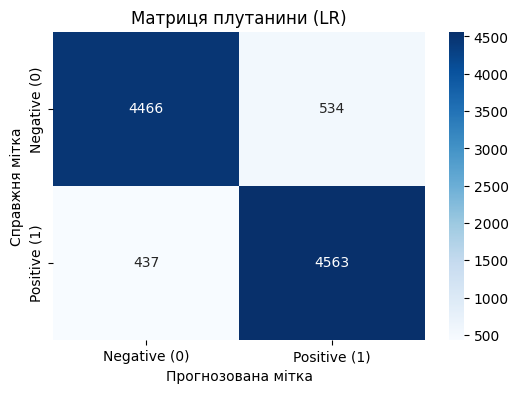


--- Тестування на довільних відгуках ---
Відгук: "This was the best movie I have ever seen. Truly brilliant!"
 -> Прогноз: ПОЗИТИВНИЙ (Впевненість: 99.14%)
--------------------
Відгук: "A complete waste of time. The acting was terrible and the plot made no sense."
 -> Прогноз: НЕГАТИВНИЙ (Впевненість: 99.61%)
--------------------
Відгук: "It was okay. Not great, but not terrible either."
 -> Прогноз: НЕГАТИВНИЙ (Впевненість: 87.91%)
--------------------
Відгук: "I absolutely loved it, despite the plot holes. <br /><br /> Fun film."
 -> Прогноз: ПОЗИТИВНИЙ (Впевненість: 84.87%)
--------------------


In [3]:
# ==============================================================================
# 1. ПРОВЕДЕМО ІМПОРТ НЕОБХІДНИХ БІБЛІОТЕК
# ==============================================================================
import pandas as pd
import numpy as np
import re  # Для видалення HTML-тегів
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 2. СТВОРИМО ФУНКЦІЮ ОЧИЩЕННЯ ТЕКСТУ
# ==============================================================================

def clean_text(text):
    """
    Функція для очищення тексту від HTML-тегів та приведення до нижнього регістру.
    """
    # 1. Видалимо HTML-теги (наприклад, <br />)
    text = re.sub(r'<[^>]+>', ' ', text)
    # 2. Приводимо до нижнього регістру
    text = text.lower()
    # 3. (Опціонально) Видалимо все, окрім літер (можна закоментувати)
    # text = re.sub(r'[^a-z\s]', '', text)
    # 4. Видалимо зайві пробіли
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ==============================================================================
# 3. ПРОВЕДЕМО ЗАВАНТАЖЕННЯ ТА ПІДГОТОВКУ ДАНИХ
# ==============================================================================

# Визначимо шлях до файлу
FILE_PATH = os.path.join("DataSet", "IMDB_Movie_Reviews.csv")

def load_data(path):
    """
    Завантажує та попередньо обробляє дані IMDB.
    """
    try:
        df = pd.read_csv(path)
        print("Дані успішно завантажено.")
        
        # 1. Очищення тексту
        print("Очищення тексту від HTML-тегів...")
        # Створюємо нову колонку з очищеним текстом
        df['review_clean'] = df['review'].apply(clean_text)
        
        # 2. Перетворення текстових міток ('positive', 'negative') у числові (1, 0)
        df['sentiment_num'] = df['sentiment'].map({'positive': 1, 'negative': 0})
        
        # 3. Перевірка на пропущені значення
        if df.isnull().values.any():
            print("Знайдено пропущені значення, видаляємо їх...")
            df = df.dropna()

        print("\n--- Перші 5 рядків даних (після обробки) ---")
        print(df[['review_clean', 'sentiment_num']].head())
        print("\n--- Розподіл класів ---")
        print(df['sentiment_num'].value_counts(normalize=True))
        
        return df

    except FileNotFoundError:
        print(f"ПОМИЛКА: Файл не знайдено за шляхом: {path}")
        print("Будь ласка, переконайтеся, що файл 'IMDB_Movie_Reviews.csv' знаходиться у папці 'DataSet'.")
        return None

df = load_data(FILE_PATH)

if df is not None and not df.empty:
    # ==============================================================================
    # 4. ПРОВЕДЕМО РОЗДІЛЕННЯ ДАНИХ
    # ==============================================================================
    
    # Визначимо X (ознаки - очищені відгуки) та y (ціль - мітка 0/1)
    X = df['review_clean']
    y = df['sentiment_num']

    # Розділимо дані на тренувальний та тестовий набори (80% / 20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y  # Датасет збалансований, але це гарна практика
    )

    print(f"\nРозмір тренувального набору: {len(X_train)}")
    print(f"Розмір тестового набору: {len(X_test)}")

    # ==============================================================================
    # 5. ПРОВЕДЕМО ВЕКТОРИЗАЦІЮ ТЕКСТУ (TF-IDF)
    # ==============================================================================
    
    print("\nСтворення TF-IDF векторайзера...")
    # 1. ngram_range=(1, 2): Врахуємо не тільки окремі слова, але й пари слів (біграми)
    #    Наприклад, по тональності (напр., "not good" vs "good")
    # 2. max_features=40000: Обмежимо словник до 40,000 найчастіших н-грам
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=40000
    )

    # Навчимо векторайзер ТІЛЬКИ на тренувальних даних
    X_train_tfidf = vectorizer.fit_transform(X_train)

    # Трансформуємо тестові дані
    X_test_tfidf = vectorizer.transform(X_test)

    print(f"Розмірність TF-IDF матриці (тренування): {X_train_tfidf.shape}")

    # ==============================================================================
    # 6. ПРОВЕДЕМО НАВЧАННЯ МОДЕЛЕЙ
    # ==============================================================================
    
    # --- Модель 1: Логістична Регресія (зазвичай швидка і точна) ---
    print("\nНавчання моделі Логістичної Регресії...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
    lr_model.fit(X_train_tfidf, y_train)
    print("Модель (LR) успішно навчено.")

    # --- Модель 2: Випадковий Ліс (Random Forest) (зазвичай повільніше) ---
    print("\nНавчання моделі Випадкового Лісу (Random Forest)...")
    # n_estimators=100 - кількість "дерев"
    # n_jobs=-1 - використаємо всі доступні ядра процесора для прискорення
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_tfidf, y_train)
    print("Модель (RF) успішно навчено.")

    # ==============================================================================
    # 7. ПРОВЕДЕМО ОЦІНКУ МОДЕЛЕЙ
    # ==============================================================================
    
    print("\n--- ОЦІНКА ЕФЕКТИВНОСТІ МОДЕЛЕЙ ---")
    
    # Прогнози
    y_pred_lr = lr_model.predict(X_test_tfidf)
    y_pred_rf = rf_model.predict(X_test_tfidf)

    # Точність
    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    print(f"Точність Логістичної Регресії: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
    print(f"Точність Випадкового Лісу:     {acc_rf:.4f} ({acc_rf*100:.2f}%)")

    # Детальний звіт для кращої моделі (зазвичай це Логістична Регресія)
    print("\n--- Детальний звіт (Логістична Регресія) ---")
    print(classification_report(y_test, y_pred_lr, target_names=['Negative (0)', 'Positive (1)']))

    # Матриця плутанини для Логістичної Регресії
    print("\nМатриця плутанини (Логістична Регресія):")
    cm = confusion_matrix(y_test, y_pred_lr)
    
    try:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Negative (0)', 'Positive (1)'], 
                    yticklabels=['Negative (0)', 'Positive (1)'])
        plt.title('Матриця плутанини (LR)')
        plt.ylabel('Справжня мітка')
        plt.xlabel('Прогнозована мітка')
        plt.show()
    except Exception as e:
        print(f"\n(Не вдалося візуалізувати матрицю: {e})")

    # ==============================================================================
    # 8. ПРОВЕДЕМО ТЕСТУВАННЯ НА НОВИХ ВІДГУКАХ
    # ==============================================================================

    print("\n--- Тестування на довільних відгуках ---")
    
    # Використаємо кращу модель (Логістичну Регресію) для прогнозів
    def predict_sentiment(text, model=lr_model):
        cleaned_text = clean_text(text)
        text_tfidf = vectorizer.transform([cleaned_text])
        prediction = model.predict(text_tfidf)[0]
        probability = model.predict_proba(text_tfidf)[0]
        
        sentiment = "ПОЗИТИВНИЙ" if prediction == 1 else "НЕГАТИВНИЙ"
        confidence = probability[prediction] * 100
        
        print(f"Відгук: \"{text}\"")
        print(f" -> Прогноз: {sentiment} (Впевненість: {confidence:.2f}%)")
        print("-" * 20)

    # Тестові приклади
    predict_sentiment("This was the best movie I have ever seen. Truly brilliant!")
    predict_sentiment("A complete waste of time. The acting was terrible and the plot made no sense.")
    predict_sentiment("It was okay. Not great, but not terrible either.")
    predict_sentiment("I absolutely loved it, despite the plot holes. <br /><br /> Fun film.")

else:
    print("\nНе вдалося завантажити дані. Подальше виконання скрипту зупинено.")


### Завдання 3. Класифікація новин за категоріями
- Опис: Розпізнайте тему новини (спорт, політика, технології тощо) за текстом. Кроки:
    - Завантажте датасет новин.
    - Побудуйте TF-IDF матрицю.
    - Навчіть модель (наприклад, MultinomialNB).
    - Побудуйте матрицю плутанини.
- Датасет: 20 Newsgroups (вбудований у sklearn) (https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html)

Завантаження тренувального набору даних...
Завантаження тестового набору даних...

Кількість тренувальних текстів: 11314
Кількість тестових текстів: 7532
Кількість категорій: 20

--- Приклад новини (тренувальний набір) ---
Категорія: rec.autos
--------------------
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.
--------------------

Створення TF-IDF векторайзера...
Розмірність TF-IDF матриці (тренування): (11314, 17797)
Розмірність TF-IDF матриці (тест): (7532, 17797)

Навчання моделі Multinomial Naive Bayes...
Модель успішно навчено.

--- ОЦІНКА ЕФЕКТИВНОСТІ МОДЕЛІ

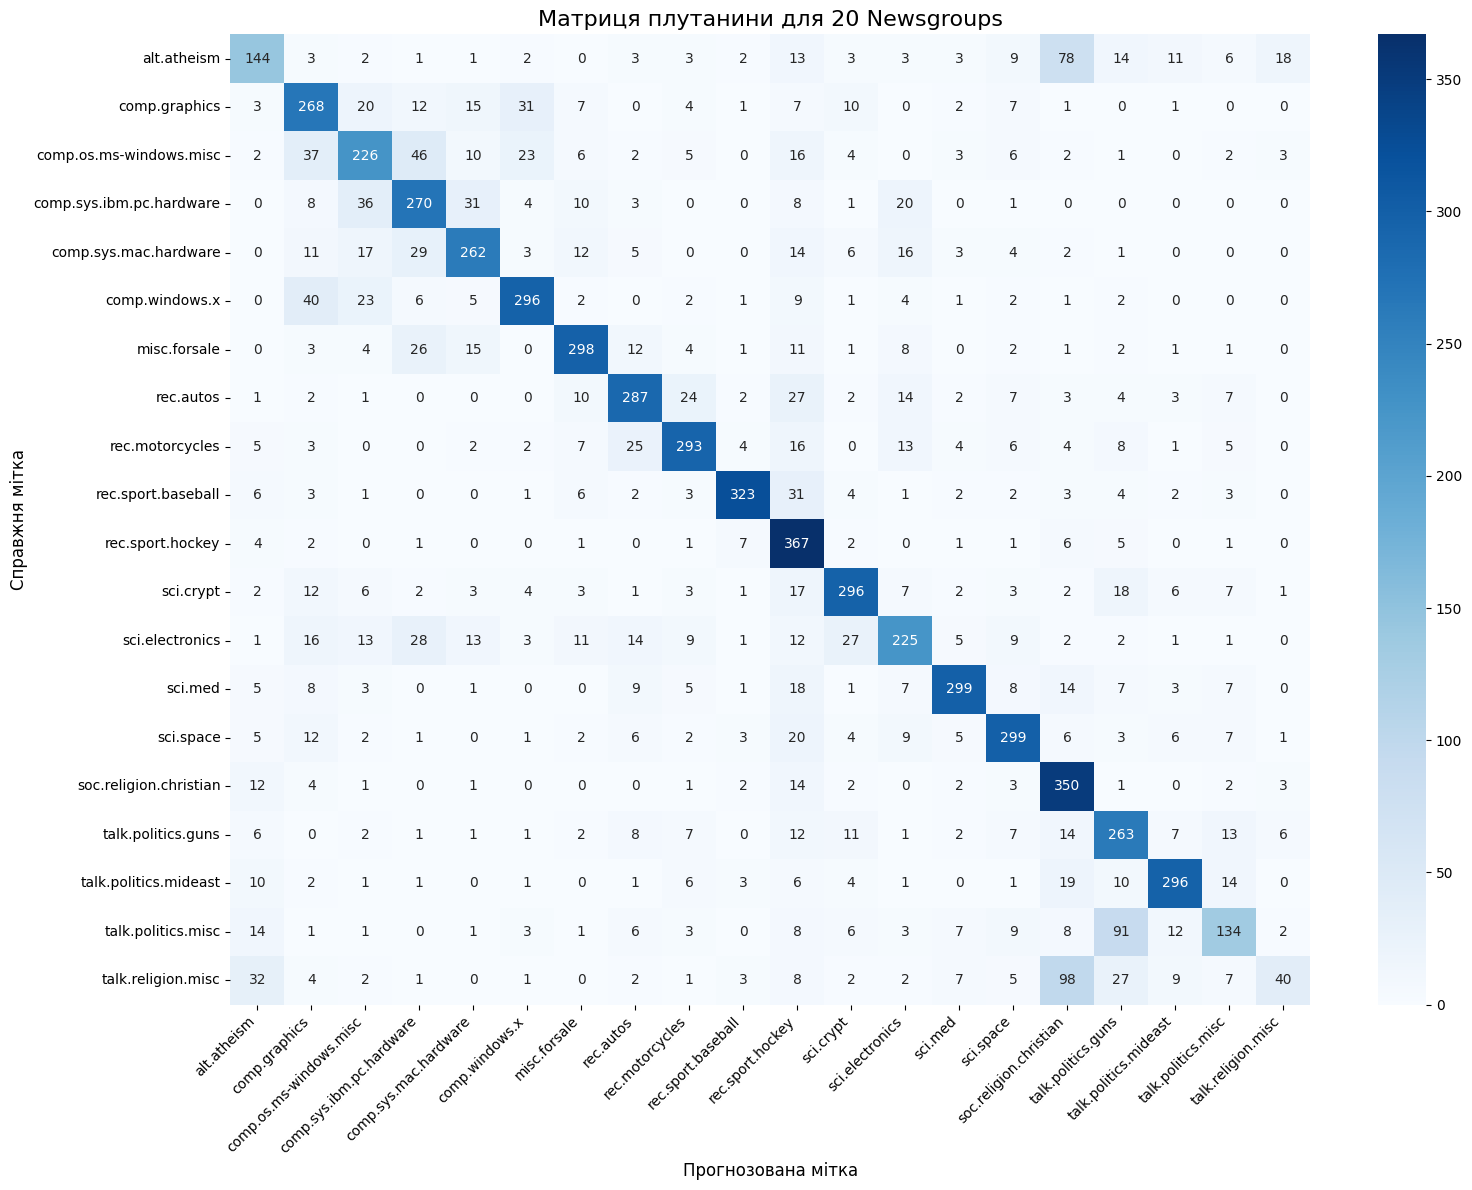


--- Тестування на довільних прикладах ---
Текст: "The new Nvidia GPU is incredibly fast for machine learning tasks...."
 -> Прогноз: comp.graphics

Текст: "The government has passed a new bill on international trade...."
 -> Прогноз: talk.politics.misc

Текст: "The Montreal Canadiens won the game against the Boston Bruins in overtime...."
 -> Прогноз: rec.sport.hockey

Текст: "Is Jesus Christ the son of God, or just a prophet?..."
 -> Прогноз: soc.religion.christian



In [4]:
# ==============================================================================
# 1. ПРОВЕДЕМО ІМПОРТ НЕОБХІДНИХ БІБЛІОТЕК
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 2. ПРОВЕДЕМО ЗАВАНТАЖЕННЯ ДАНИХ (вбудований датасет sklearn)
# ==============================================================================

# Датасет "20 Newsgroups" вже розділений на тренувальний та тестовий набори
# remove=('headers', 'footers', 'quotes') - очищує текст від метаданих,

print("Завантаження тренувального набору даних...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print("Завантаження тестового набору даних...")
newsgroups_test = fetch_20newsgroups(
    subset='test',
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"\nКількість тренувальних текстів: {len(newsgroups_train.data)}")
print(f"Кількість тестових текстів: {len(newsgroups_test.data)}")
print(f"Кількість категорій: {len(newsgroups_train.target_names)}")

# Виведемо приклад
print("\n--- Приклад новини (тренувальний набір) ---")
print(f"Категорія: {newsgroups_train.target_names[newsgroups_train.target[0]]}")
print("-" * 20)
print(newsgroups_train.data[0].strip())
print("-" * 20)

# ==============================================================================
# 3. ПРОВЕДЕМО ВЕКТОРИЗАЦІЯ ТЕКСТУ (TF-IDF)
# ==============================================================================

print("\nСтворення TF-IDF векторайзера...")
# stop_words='english' - видаляє поширені слова
# max_df=0.5 - ігнорує слова, які зустрічаються у > 50% документів (занадто загальні)
# min_df=5 - ігнорує слова, які зустрічаються менше 5 разів (занадто рідкісні)
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    max_df=0.5,
    min_df=5
)

# Навчимо векторайзер на тренувальних даних
X_train_tfidf = vectorizer.fit_transform(newsgroups_train.data)

# Трансформуємо тестові дані
X_test_tfidf = vectorizer.transform(newsgroups_test.data)

# Визначимо цільові змінні (мітки)
y_train = newsgroups_train.target
y_test = newsgroups_test.target

print(f"Розмірність TF-IDF матриці (тренування): {X_train_tfidf.shape}")
print(f"Розмірність TF-IDF матриці (тест): {X_test_tfidf.shape}")

# ==============================================================================
# 4. ПРОВЕДЕМО НАВЧАННЯ МОДЕЛІ (Multinomial Naive Bayes)
# ==============================================================================

# MultinomialNB (Мультиноміальний Наївний Баєс)
print("\nНавчання моделі Multinomial Naive Bayes...")

model = MultinomialNB(alpha=0.1) # alpha - параметр згладжування

# Навчимо модель
model.fit(X_train_tfidf, y_train)

print("Модель успішно навчено.")

# ==============================================================================
# 5. ПРОВЕДЕМО ОЦІНКА МОДЕЛІ
# ==============================================================================

print("\n--- ОЦІНКА ЕФЕКТИВНОСТІ МОДЕЛІ ---")

# Робимо прогнози на тестових даних
y_pred = model.predict(X_test_tfidf)

# 1. Точність (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Загальна точність (Accuracy): {accuracy:.4f} (або {accuracy*100:.2f}%)")

# 2. Звіт про класифікацію (Precision, Recall, F1-score)
print("\nЗвіт про класифікацію:")
# Використовуємо target_names для читабельних міток
print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))

# ==============================================================================
# 6. ПРОВЕДЕМО МАТРИЦЯ ПЛУТАНИНИ (Confusion Matrix)
# ==============================================================================

print("\nПобудова матриці плутанини...")

cm = confusion_matrix(y_test, y_pred)

# Візуалізація матриці
try:
    # Робимо візуалізацію великою, щоб помістилися всі 20 категорій
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        cm, 
        annot=True, # показувати числа у клітинках
        fmt='d',      # формат чисел (цілі)
        cmap='Blues',
        xticklabels=newsgroups_train.target_names,
        yticklabels=newsgroups_train.target_names
    )
    plt.title('Матриця плутанини для 20 Newsgroups', fontsize=16)
    plt.ylabel('Справжня мітка', fontsize=12)
    plt.xlabel('Прогнозована мітка', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout() # для коректного відображення
    plt.show()

except ImportError:
    print("\n(Для візуалізації матриці, будь ласка, встановіть 'matplotlib' та 'seaborn')")
except Exception as e:
    print(f"\nНе вдалося візуалізувати матрицю: {e}")
    print("Матриця плутанини (текстовий вигляд):")
    print(cm)

# ==============================================================================
# 7. ПРОВЕДЕМО ТЕСТУВАННЯ НА НОВИХ ПОВІДОМЛЕННЯХ
# ==============================================================================

print("\n--- Тестування на довільних прикладах ---")

def predict_category(text, model, vectorizer, target_names):
    """
    Функція для прогнозування категорії нового тексту.
    """
    # 1. Векторизуємо текст
    text_tfidf = vectorizer.transform([text])
    
    # 2. Робимо прогноз
    pred_index = model.predict(text_tfidf)[0]
    
    # 3. Отримуємо назву категорії
    category_name = target_names[pred_index]
    
    print(f"Текст: \"{text[:100]}...\"")
    print(f" -> Прогноз: {category_name}\n")

# Приклади
predict_category("The new Nvidia GPU is incredibly fast for machine learning tasks.",
                 model, vectorizer, newsgroups_train.target_names)

predict_category("The government has passed a new bill on international trade.",
                 model, vectorizer, newsgroups_train.target_names)

predict_category("The Montreal Canadiens won the game against the Boston Bruins in overtime.",
                 model, vectorizer, newsgroups_train.target_names)

predict_category("Is Jesus Christ the son of God, or just a prophet?",
                 model, vectorizer, newsgroups_train.target_names)


### Завдання 4. Аналіз сентименту твітів (позитивний/негативний/нейтральний)
- Опис: Навчіть модель визначати настрій твітів. Кроки:
    - Завантажте твіттер-датасет.
    - Обробіть текст.
    - Навчіть класифікатор.
    - Оцініть точність.
- Датасет: Kaggle - Twitter Sentiment Analysis (https://www.kaggle.com/datasets/kazanova/sentiment140)    

### Завдання 5. Прогноз довжини огляду за кількістю слів (регресія)
- Опис: Спробуйте передбачити кількість символів у тексті, виходячи з кількості слів. Кроки:
    - Згенеруйте дані або візьміть датасет відгуків.
    - Порахуйте кількість слів і символів.
    - Навчіть регресійну модель.
    - Оцініть MAE або RMSE.
- Датасет: Будь-який відкритий текстовий датасет (наприклад, Amazon Reviews) (https://www.kaggle.com/datasets/bittlingmayer/amazonreviews)

### Завдання 6. Бінарна класифікація токсичних коментарів
- Опис: Навчіть модель розпізнавати токсичні коментарі. Кроки:
    - Завантажте дані.
    - Попередня обробка.
    - TF-IDF та модель Logistic Regression.
    - Оцініть якість.
- Датасет: Kaggle - Toxic Comment Classification Challenge (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data)

### Завдання 7. Завдання на мультикласову класифікацію новин BBC
- Опис: Класифікуйте новини BBC за категоріями. Кроки:
    - Завантажте датасет.
    - Побудуйте TF-IDF.
    - Навчіть модель.
    - Виведіть точність та звіт про класифікацію.
- Датасет: Kaggle - BBC News Dataset

### Завдання 8. Класифікація e-mail листів за темою (спам, робота, особисте тощо)
- Опис: Навчіть модель класифікувати листи за категоріями. Кроки:
    - Завантажте датасет листів.
    - Очистіть тексти.
    - Створіть модель.
    - Оцініть точність.
- Датасет: Enron Email Dataset (https://www.kaggle.com/datasets/wcukierski/enron-email-dataset)

### Завдання 9. Класифікація на базі n-грамів (біграми/триграми)
- Опис: Дослідіть, чи покращиться класифікація, якщо використовувати біграми або триграми. Кроки:
    - Завантажте будь-який текстовий датасет.
    - Використайте CountVectorizer з ngram_range=(1,2) або (1,3).
    - Навчіть модель.
    - Порівняйте результат із звичайними уніграмами.

### Завдання 10. Просте завдання на класифікацію з використанням готових embeddings
- Опис: Спробуйте використовувати попередньо навчені векторні представлення слів (наприклад, GloVe) для текстової класифікації. Кроки:
    - Завантажте датасет.
    - Скачайте GloVe embeddings.
    - Побудуйте середнє векторне представлення для текстів.
    - Навчіть модель.
- GloVe: https://nlp.stanford.edu/projects/glove/